In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from _plot_utils import add_aggregate_loss

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

/var/folders/ck/2h92ww3n7f934h0f58607dljk8_14b/T/ipykernel_85934/3368845505.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap("GnBu_r", 7)
/var/folders/ck/2h92ww3n7f934h0f58607dljk8_14b/T/ipykernel_85934/3368845505.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap("OrRd_r", 7)


FineWeb/16, adam: 2.975, sgd: 2.964, gap: 0.010, gap(%): 0.34
FineWeb/64, adam: 2.976, sgd: 2.971, gap: 0.005, gap(%): 0.16
FineWeb/256, adam: 2.939, sgd: 3.189, gap: -0.250, gap(%): -8.52
FineWeb/1024, adam: 3.103, sgd: 4.190, gap: -1.087, gap(%): -35.03
I21K/1024, adam: 5.842, sgd: 5.593, gap: 0.249, gap(%): 4.27
I21K/4096, adam: 5.686, sgd: 6.082, gap: -0.396, gap(%): -6.96


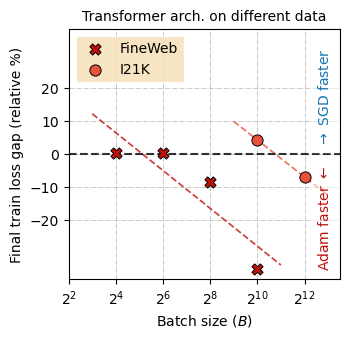

In [ ]:
ema_alpha = 0.01
relative = True  # True: gap / sgd_best, False: gap absolute
metric = "tr_loss_ema"
betas = [0.9, 0.95, 0.99, 0.999]

datasets = [
    ("_results/gap_fineweb.csv", "FineWeb", [16, 64, 256, 1024]),
    ("_results/gap_i21k_vit.csv", "I21K", [256, 1024, 4096]),
    ("_results/gap_zinc250k_grit.csv", "ZINC", [16, 64, 256, 1024]),
    ("_results/gap_hg38_char.csv", "HG38", [4, 16, 64, 256, 1024]),
]

cmap_b = plt.cm.get_cmap("GnBu_r", 7)
cmap_r = plt.cm.get_cmap("OrRd_r", 7)
colors = [cmap_r(i + 1) for i in range(len(datasets))]
markers = ["X", "o", "P", "v"]

fig, ax = plt.subplots(figsize=(3.5, 3.25))

for (csv_path, label, bss), color, marker in zip(datasets, colors, markers):
    df = pd.read_csv(csv_path)
    df = add_aggregate_loss(df, ema_alpha=ema_alpha)

    x, y = [], []
    for bs in bss:
        df_bs = df[df["bs"] == bs]
        y_adam, y_sgd = [], []
        for beta in betas:
            df_beta = df_bs[df_bs["mom"] == beta]
            adam = df_beta[df_beta["opt"] == "adam"]
            sgd = df_beta[df_beta["opt"] == "sgd"]
            y_adam.append(adam[metric].min())
            y_sgd.append(sgd[metric].min())
        x.append(bs)
        min_adam, min_sgd = min(y_adam), min(y_sgd)
        gap = min_adam - min_sgd
        y.append((gap / min_adam) * 100 if relative else gap)

        print(f"{label}/{bs}, adam: {min_adam:.3f}, sgd: {min_sgd:.3f}, gap: {gap:.3f}, gap(%): {y[-1]:.2f}")  # fmt: skip

    x, y = np.array(x), np.array(y)
    ax.scatter(
        x,
        y,
        color=color,
        marker=marker,
        s=65,
        edgecolors="black",
        linewidth=0.7,
        zorder=3,
        label=label,
    )

    # linear fit in log2(bs) space
    log_bss = np.log2(bss)
    coeffs = np.polyfit(log_bss, y, 1)
    x_fit = np.linspace(log_bss[0] - 1, log_bss[-1] + 1, 200)
    ax.plot(
        2**x_fit, np.polyval(coeffs, x_fit), color=color, lw=1.25, ls="--", alpha=0.8
    )

ax.annotate(
    r"$\rightarrow$ SGD faster",
    xy=(0.945, 0.53),
    xycoords="axes fraction",
    fontsize=10,
    color=cmap_b(1),
    ha="center",
    va="bottom",
    rotation=90,
    zorder=4,
    bbox=dict(edgecolor="white", facecolor="white", alpha=0.5),
)
ax.annotate(
    r"Adam faster $\leftarrow$ ",
    xy=(0.945, 0.47),
    xycoords="axes fraction",
    fontsize=10,
    color=cmap_r(1),
    ha="center",
    va="top",
    rotation=90,
    zorder=4,
    bbox=dict(edgecolor="white", facecolor="white", alpha=0.5),
)

ax.set_title("Transformer arch. on different data", fontsize=10)
ax.axhline(0, color="black", lw=1.5, ls="--", alpha=0.8)
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=4))
ax.set_ylim(-38.0, 38.0)
ax.set_xscale("log", base=2)
ax.set_xticks([4, 16, 64, 256, 1024, 4096])
ax.set_yticks([-20, -10, 0, 10, 20])
ax.set_xlabel("Batch size $(B)$")
ax.set_ylabel("Final train loss gap (relative %)")
ax.grid(True, ls="-.", lw=0.5)
ax.legend(
    frameon=True,
    fancybox=False,
    edgecolor="white",
    facecolor="wheat",
    loc="upper left",
)
# plt.savefig("_figures/figure1_1.pdf", format="pdf", dpi=300, bbox_inches="tight")

/var/folders/ck/2h92ww3n7f934h0f58607dljk8_14b/T/ipykernel_85934/3158789581.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap("GnBu_r", 7)
/var/folders/ck/2h92ww3n7f934h0f58607dljk8_14b/T/ipykernel_85934/3158789581.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap("OrRd_r", 7)


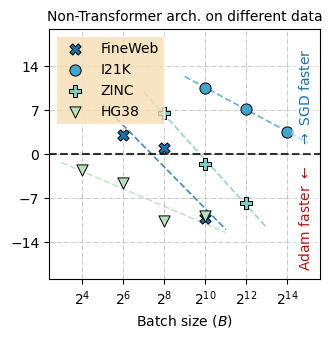

In [ ]:
ema_alpha = 0.01
relative = True  # True: gap / sgd_best, False: gap absolute
betas = [0.9, 0.95, 0.99, 0.999]

datasets = [
    ("_results/gap_fineweb_gcnn.csv", "FineWeb", [64, 256, 1024]),
    ("_results/gap_i21k_resnet50.csv", "I21K", [256, 1024, 4096, 16384]),
    ("_results/gap_zinc250k_gat.csv", "ZINC", [256, 1024, 4096]),
    ("_results/gap_hg38_char_gdn.csv", "HG38", [16, 64, 256, 1024]),
]

cmap_b = plt.cm.get_cmap("GnBu_r", 7)
cmap_r = plt.cm.get_cmap("OrRd_r", 7)
colors = [cmap_b(i + 1) for i in range(len(datasets))]
markers = ["X", "o", "P", "v"]

fig, ax = plt.subplots(figsize=(3.5, 3.25))

for (csv_path, label, bss), color, marker in zip(datasets, colors, markers):
    df = pd.read_csv(csv_path)
    df = add_aggregate_loss(df, ema_alpha=ema_alpha)

    x, y = [], []
    for bs in bss:
        df_bs = df[df["bs"] == bs]
        y_adam, y_sgd = [], []
        for beta in betas:
            df_beta = df_bs[df_bs["mom"] == beta]
            adam = df_beta[df_beta["opt"] == "adam"]
            sgd = df_beta[df_beta["opt"] == "sgd"]
            y_adam.append(adam["tr_loss_ema"].min())
            y_sgd.append(sgd["tr_loss_ema"].min())
        x.append(bs)
        gap = min(y_adam) - min(y_sgd)
        y.append((gap / min(y_adam)) * 100 if relative else gap)

    x, y = np.array(x), np.array(y)
    ax.scatter(
        x,
        y,
        color=color,
        marker=marker,
        s=65,
        edgecolors="black",
        linewidth=0.7,
        zorder=3,
        label=label,
    )

    log_bss = np.log2(bss)
    coeffs = np.polyfit(log_bss, y, 1)
    x_fit = np.linspace(log_bss[0] - 1, log_bss[-1] + 1, 200)
    ax.plot(
        2**x_fit, np.polyval(coeffs, x_fit), color=color, lw=1.25, ls="--", alpha=0.8
    )

ax.annotate(
    r"$\rightarrow$ SGD faster",
    xy=(0.945, 0.53),
    xycoords="axes fraction",
    fontsize=10,
    color=cmap_b(1),
    ha="center",
    va="bottom",
    rotation=90,
    zorder=4,
    bbox=dict(edgecolor="white", facecolor="white", alpha=0.5),
)
ax.annotate(
    r"Adam faster $\leftarrow$ ",
    xy=(0.945, 0.47),
    xycoords="axes fraction",
    fontsize=10,
    color=cmap_r(1),
    ha="center",
    va="top",
    rotation=90,
    zorder=4,
    bbox=dict(edgecolor="white", facecolor="white", alpha=0.5),
)

ax.set_title("Non-Transformer arch. on different data", fontsize=10)
ax.axhline(0, color="black", lw=1.5, ls="--", alpha=0.8)
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=4))
ax.set_ylim(-20.0, 20.0)
ax.set_xscale("log", base=2)
ax.set_xticks([16, 64, 256, 1024, 4096, 16384])
ax.set_yticks([-14, -7, 0, 7, 14])
ax.set_xlabel("Batch size $(B)$")
ax.set_ylabel("Final train loss gap (relative %)")
ax.grid(True, ls="-.", lw=0.5)
ax.legend(
    frameon=True,
    fancybox=False,
    edgecolor="white",
    facecolor="wheat",
    loc="upper left",
)
plt.savefig("_figures/figure1_2.pdf", format="pdf", dpi=300, bbox_inches="tight")

/var/folders/ck/2h92ww3n7f934h0f58607dljk8_14b/T/ipykernel_19167/271201996.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap("OrRd_r", 7)
/var/folders/ck/2h92ww3n7f934h0f58607dljk8_14b/T/ipykernel_19167/271201996.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap("GnBu_r", 7)


bs=1024, ep=1, adam: 6.200, sgd: 5.946, gap: 0.254, gap(%): 4.09
bs=1024, ep=4, adam: 4.779, sgd: 4.681, gap: 0.098, gap(%): 2.05
bs=1024, ep=16, adam: 4.080, sgd: 4.020, gap: 0.060, gap(%): 1.47
bs=4096, ep=1, adam: 6.195, sgd: 6.337, gap: -0.142, gap(%): -2.29
bs=4096, ep=4, adam: 4.867, sgd: 4.949, gap: -0.082, gap(%): -1.70
bs=4096, ep=16, adam: 4.017, sgd: 4.042, gap: -0.025, gap(%): -0.63


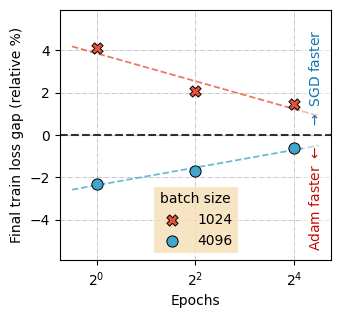

In [34]:
csv_paths = [
    "_results/gap_i21k_vit.csv",
    "_results/gap_i21k_vit_ep4.csv",
    "_results/gap_i21k_vit_ep16.csv",
]
bss = [1024, 4096]
epochs = [1, 4, 16]
window = 0.01  # percentage of the total steps
ema_alpha = 0.01

df = add_aggregate_loss(
    pd.concat([pd.read_csv(p) for p in csv_paths]), window=window, ema_alpha=ema_alpha
)

cmap_r = plt.cm.get_cmap("OrRd_r", 7)
cmap_b = plt.cm.get_cmap("GnBu_r", 7)
colors = [cmap_r(2), cmap_b(2)]
markers = ["X", "o"]

fig, ax = plt.subplots(figsize=(3.5, 3.25))

for bs, color, marker in zip(bss, colors, markers):
    y = []
    for ep in epochs:
        df_bs_ep = df[(df["bs"] == bs) & (df["ep"] == ep)]
        min_adam = df_bs_ep[df_bs_ep["opt"] == "adam"]["tr_loss_ema"].min()
        min_sgd = df_bs_ep[df_bs_ep["opt"] == "sgd"]["tr_loss_ema"].min()
        gap = min_adam - min_sgd
        y.append((gap / min_adam) * 100)
        print(f"bs={bs}, ep={ep}, adam: {min_adam:.3f}, sgd: {min_sgd:.3f}, gap: {gap:.3f}, gap(%): {y[-1]:.2f}")  # fmt: skip
    ax.scatter(
        epochs,
        y,
        color=color,
        marker=marker,
        s=65,
        edgecolors="black",
        linewidth=0.7,
        zorder=3,
        label=bs,
    )

    log_bss = np.log2(epochs)
    coeffs = np.polyfit(log_bss, y, 1)
    x_fit = np.linspace(log_bss[0] - 0.5, log_bss[-1] + 0.5, 200)
    ax.plot(
        2**x_fit, np.polyval(coeffs, x_fit), color=color, lw=1.25, ls="--", alpha=0.8
    )

ax.annotate(
    r"$\rightarrow$ SGD faster",
    xy=(0.945, 0.53),
    xycoords="axes fraction",
    fontsize=10,
    color=cmap_b(1),
    ha="center",
    va="bottom",
    rotation=90,
    zorder=4,
    bbox=dict(edgecolor="white", facecolor="white", alpha=0.5),
)
ax.annotate(
    r"Adam faster $\leftarrow$ ",
    xy=(0.945, 0.47),
    xycoords="axes fraction",
    fontsize=10,
    color=cmap_r(1),
    ha="center",
    va="top",
    rotation=90,
    zorder=4,
    bbox=dict(edgecolor="white", facecolor="white", alpha=0.5),
)

ax.axhline(0, color="black", lw=1.5, ls="--", alpha=0.8)
ax.set_ylim(-5.9, 5.9)
ax.set_xlabel("Epochs")
ax.set_ylabel("Final train loss gap (relative %)")
ax.set_xscale("log", base=2)
ax.set_xticks(epochs)
ax.grid(True, ls="-.", lw=0.5)
ax.legend(
    title="batch size",
    frameon=True,
    fancybox=False,
    loc="lower center",
    edgecolor="white",
    facecolor="wheat",
)
plt.savefig(
    "_figures/gap_i21k_vit_steps.pdf", format="pdf", dpi=300, bbox_inches="tight"
)